# MEVerse (TradeX) — GRPO Fine-tuning of Qwen3-1.7B (Unsloth)

**OpenEnv Hackathon — Round 2 Training Notebook**

This notebook fine-tunes a small instruction-tuned LLM to act as a *market surveillance controller* on the MEVerse OpenEnv environment using **GRPO (Group Relative Policy Optimization)** via Hugging Face TRL.

The agent observes 16-dim AMM market signals (burst indicator, pattern indicator, suspiciousness score, manipulation score, trade frequency, etc.) and must output one of four actions per step:

- `ALLOW`  — normal activity, let it through
- `FLAG`   — mark as suspicious
- `BLOCK`  — stop the activity
- `MONITOR` — watch closely, no immediate action

**Stack** — Unsloth-accelerated:
- `unsloth` `FastLanguageModel` for fast, low-VRAM model loading + **4-bit** quantization
- **LoRA** adapters via Unsloth (only adapters are trained)
- `trl` for the **GRPO** trainer
- `fastapi` + `uvicorn` to host the OpenEnv server inside the Colab runtime on `localhost:7860`

**Pipeline**

1. Spin up the OpenEnv FastAPI server *inside the Colab runtime* on `localhost:7860` (cloning the HF Space — no Docker needed).
2. Run a baseline rollout with the un-finetuned 4-bit model across all 3 tasks.
3. Run GRPO with a custom reward function that calls `env.step()` and returns the env reward. Only LoRA adapters are updated.
4. Run a post-training rollout, plot reward curves and baseline-vs-trained comparison, save PNGs + adapters.

**Targets / Judge expectations**
- Reward column should *increase* over training steps (judges look for this).
- `plots/reward_vs_training_step.png` and `plots/baseline_vs_trained.png` committed to the repo.

> Runtime: Colab T4 (free) works thanks to 4-bit + LoRA. With a beefier GPU (A100/L4) you can bump `MODEL_NAME` to `unsloth/Qwen3-4B-Instruct-2507` without changing anything else.


## 1. Install dependencies

We install **Unsloth** + TRL for fast, low-VRAM GRPO training, plus only the
**server-side** dependencies of MEVerse (`fastapi`, `uvicorn`, `pydantic`) — *not*
Gradio or the full UI stack.

Version pins are lifted from the Qwen3 Unsloth reference notebook (triton 3.2.0 on
T4, `transformers==4.56.2`, `trl==0.22.2`) so they don't collide with Colab's
preinstalled packages.

In [1]:
%%capture
# Unsloth + TRL stack pinned for FREE-TIER Colab (Tesla T4).
# Pins lifted from the Qwen3 Unsloth reference notebook to avoid the
# torch / cu130 dependency collisions that previously broke Colab.
import os

!pip install --upgrade -qqq uv

if "COLAB_" not in "".join(os.environ.keys()):
    # Non-Colab: a plain install resolves fine.
    !pip install -qqq unsloth unsloth_zoo
else:
    try:
        import numpy
        _numpy = f"numpy=={numpy.__version__}"
    except Exception:
        _numpy = "numpy"
    # Tesla T4 needs triton 3.2.0; newer GPUs take the default.
    try:
        import subprocess
        is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except Exception:
        is_t4 = False
    _triton = "triton==3.2.0" if is_t4 else "triton"
    !uv pip install -qqq --upgrade {_numpy} torchvision bitsandbytes xformers unsloth unsloth_zoo
    !uv pip install -qqq {_triton}
    !uv pip install -qqq --no-deps --upgrade "torchao>=0.16.0"

# Pin the transformers / trl pair Unsloth is validated against (avoids API drift).
!uv pip install -qqq transformers==4.56.2
!uv pip install -qqq --no-deps trl==0.22.2

# MEVerse server-side deps (no Gradio / UI).
!uv pip install -qqq fastapi "uvicorn[standard]" pydantic requests matplotlib openai

# OpenEnv (meverse imports openenv.core.env_server.types)
!uv pip install -qqq "openenv-core" || uv pip install -qqq "git+https://github.com/meta-pytorch/OpenEnv.git@83dda10"

# Remove the optional video/audio stack that is crashing the Unsloth import here.
# The notebook does not use torchcodec, so uninstalling it is the smallest safe fix.
!uv pip uninstall -y torchcodec || true

# bitsandbytes is looking for the CUDA JIT linker library on this cu130 runtime.
!uv pip install -qqq nvidia-nvjitlink

# Ensure latest Unsloth (fixes compatibility with torch upgrades).
!pip install -U unsloth

# Minimal compatibility repair for torch + CUDA: reinstall triton.
!pip uninstall -y triton
!pip install -U triton


### ⚠️ Restart the runtime now

Running the install cell upgrades a few packages (notably `numpy`) that have C extensions.
The kernel still has the **old** versions in memory — so before continuing, **restart the runtime once**:

`Runtime → Restart session` (or press the ▶️ on the cell below — it will force-restart for you).

After restart, **skip cell 1** (already installed) and run from cell 2 onwards.

In [ ]:
# Restart the runtime ONCE so the freshly-installed packages load.
# Idempotent: a sentinel file prevents a second kill if you re-run this cell,
# so re-running the notebook top-to-bottom won't hang on a restart loop.
import os

_SENTINEL = "/tmp/_deps_restarted"
if os.path.exists(_SENTINEL):
    print("Runtime already restarted for this session - skipping.")
    print(f"(Delete {_SENTINEL} if you reinstalled deps and need another restart.)")
else:
    open(_SENTINEL, "w").close()
    print("Restarting runtime to load freshly-installed packages...")
    os.kill(os.getpid(), 9)


## 2. Start the MEVerse OpenEnv server on `localhost:7860`

Rather than building the full Docker image inside Colab (slow, and pulls in Gradio), we clone the HF Space repo and start **only** the FastAPI OpenEnv server. The Gradio dashboard never boots — we just need the `/reset` and `/step` endpoints.

If the HF Space repo path differs (e.g. private, different owner), update `HF_SPACE_REPO` below.

In [1]:
# Clone the public HF Space — this gives us the meverse/ package
HF_SPACE_REPO = "https://huggingface.co/spaces/Casp1an/TradeXv2"
SPACE_DIR = "/content/meverse_space"

import os, shutil, subprocess

if os.path.exists(SPACE_DIR):
    shutil.rmtree(SPACE_DIR)

# git lfs not required — server code is small Python files
!git clone {HF_SPACE_REPO} {SPACE_DIR}
!ls {SPACE_DIR}

Cloning into '/content/meverse_space'...
remote: Enumerating objects: 573, done.
remote: Total 573 (delta 0), reused 0 (delta 0), pack-reused 573 (from 1)
Receiving objects: 100% (573/573), 558.10 KiB | 3.60 MiB/s, done.
Resolving deltas: 100% (311/311), done.
app.py		     Dockerfile    prompt_optimizer.py	server
client.py	     docs	   __pycache__		telemetry
compare_policies.py  inference.py  pyproject.toml	tradex
context		     meverse	   README.md		uv.lock
dashboard.py	     openenv.yaml  requirements.txt	validate_submission.sh


In [2]:
import subprocess, time, sys, os, requests

# Likely server entry points — first match wins
CANDIDATES = [
    # meverse/server/app.py defines `app = create_app(...)` — FastAPI only, NO gradio.
    # Root app.py is avoided here: it does `import gradio` at top level, but this
    # notebook installs server-side deps only (no gradio), so importing it fails.
    "meverse.server.app:app",
    "server.app:app",        # same module if repo root is the server/ dir
    "app:app",               # last resort: root entrypoint (needs gradio installed)
]

# Inspect repo to pick a candidate
def _candidate_exists(cand: str) -> bool:
    mod_path = cand.split(":")[0].replace(".", "/")
    return os.path.exists(os.path.join(SPACE_DIR, mod_path + ".py")) or \
           os.path.exists(os.path.join(SPACE_DIR, mod_path, "__init__.py"))

SERVER_MODULE = next((c for c in CANDIDATES if _candidate_exists(c)), CANDIDATES[0])
print(f"Using server module: {SERVER_MODULE}")

# Kill anything already on 7860
!fuser -k 7860/tcp 2>/dev/null || true

# Quick import sanity check before launching uvicorn — surface import errors early.
# NOTE: importing `app` pulls in gradio + openenv + fastapi, and on a cold Colab
# runtime that first-time import (disk read + bytecode compile) can take well over
# 30s. A timeout here does NOT mean failure — the real readiness gate is the /docs
# poll below. So we only hard-fail on a non-zero return code (a genuine import error),
# and treat a timeout as "slow import, proceed".
print("\nPre-flight import check...")
PREFLIGHT_TIMEOUT = 120
try:
    preflight = subprocess.run(
        [sys.executable, "-c", f"import sys; sys.path.insert(0, '{SPACE_DIR}'); "
                                f"mod = '{SERVER_MODULE}'.split(':')[0]; "
                                f"__import__(mod); print('import OK')"],
        cwd=SPACE_DIR, capture_output=True, text=True, timeout=PREFLIGHT_TIMEOUT,
    )
    if preflight.returncode != 0:
        print("PRE-FLIGHT FAILED — the env package can't be imported in this Colab runtime.")
        print("STDOUT:", preflight.stdout)
        print("STDERR:", preflight.stderr)
        print("\nIf the error is about 'openenv' not being found, re-run cell 1 (install).")
        raise RuntimeError("Pre-flight import failed — see error above")
    print(preflight.stdout.strip())
except subprocess.TimeoutExpired:
    print(f"Pre-flight import slow (>{PREFLIGHT_TIMEOUT}s) — likely a cold gradio/openenv "
          "import, not a real error. Proceeding to launch; the /docs poll below is the "
          "real readiness check.")

LOG_FILE = "/content/meverse_server.log"
# PYTHONPATH ensures the meverse package is importable from SPACE_DIR
env = os.environ.copy()
env["PYTHONPATH"] = SPACE_DIR + ":" + env.get("PYTHONPATH", "")

proc = subprocess.Popen(
    ["uvicorn", SERVER_MODULE, "--host", "0.0.0.0", "--port", "7860"],
    cwd=SPACE_DIR,
    env=env,
    stdout=open(LOG_FILE, "w"),
    stderr=subprocess.STDOUT,
)
print(f"Server PID: {proc.pid} | logs: {LOG_FILE}")

# Wait for server to come up — poll /docs (FastAPI default) for up to 120s.
# Cold import of gradio + openenv inside uvicorn can take a while on free-tier Colab.
MEVERSE_URL = "http://localhost:7860"
ready = False
for i in range(120):
    # Bail early if the process died
    if proc.poll() is not None:
        print(f"\nServer process exited with code {proc.returncode} after {i}s.")
        print("--- server log (last 50 lines) ---")
        !tail -50 {LOG_FILE}
        raise RuntimeError("MEVerse server crashed on startup — see log above")
    try:
        r = requests.get(f"{MEVERSE_URL}/docs", timeout=20)
        if r.status_code == 200:
            print(f"Server ready after {i}s")
            ready = True
            break
    except Exception:
        pass
    time.sleep(1)

if not ready:
    print("Server did not respond in 120s — check the log:")
    !tail -60 {LOG_FILE}
    raise RuntimeError("MEVerse server failed to start")


Using server module: meverse.server.app:app

Pre-flight import check...
import OK
Server PID: 13810 | logs: /content/meverse_server.log
Server ready after 14s


In [3]:
# Sanity check: reset the env and inspect a baseline observation
import requests, json

resp = requests.post(f"{MEVERSE_URL}/reset", json={"task_name": "burst_detection", "seed": 42})
print("Status:", resp.status_code)
print(json.dumps(resp.json(), indent=2)[:1500])

Status: 200
{
  "observation": {
    "current_amm_price": 101.2498,
    "liquidity_snapshot": 20000.0,
    "recent_trade_count": 5,
    "trades_in_window": [
      9.5097,
      12.0952,
      11.8098,
      12.8932,
      12.7903
    ],
    "trade_frequency": 0.9816,
    "average_trade_size": 11.8196,
    "maximum_trade_size": 12.8932,
    "recent_slippage_impact": 0.0049,
    "time_gap_mean": 5.0935,
    "time_gap_min": 3.9309,
    "recent_time_gaps": [
      4.5245,
      4.6492,
      3.9309,
      6.4136,
      5.9495
    ],
    "recent_price_impacts": [
      0.0033,
      0.0054,
      0.0042,
      0.0037,
      0.0081
    ],
    "suspiciousness_score": 0.4013,
    "manipulation_score": 0.1527,
    "step_num": 0,
    "max_steps": 50,
    "task_name": "burst_detection"
  },
  "reward": 0.0,
  "done": false
}


## 3. Environment client helpers

Thin wrappers around `/reset` and `/step`. These are what the GRPO reward function will call — one rollout = many `env_step` calls.

The MEVerse server returns observations under different keys depending on the OpenEnv adapter version, so we normalize with `_extract_observation` to handle both `{"observation": {...}}` and flat-dict responses.

In [4]:
import requests
from typing import Dict, Any, Tuple
import json

VALID_ACTIONS = ["ALLOW", "FLAG", "BLOCK", "MONITOR"]
TASKS = ["burst_detection", "pattern_manipulation_detection", "full_market_surveillance"]


def _extract_observation(payload: Dict[str, Any]) -> Dict[str, Any]:
    if "observation" in payload and isinstance(payload["observation"], dict):
        return payload["observation"]
    return payload


def env_reset(task_name: str, seed: int = 42) -> Dict[str, Any]:
    r = requests.post(
        f"{MEVERSE_URL}/reset",
        json={"task_name": task_name, "seed": seed},
        timeout=15,
    )
    r.raise_for_status()
    return _extract_observation(r.json())


def env_step(action: str) -> Tuple[Dict[str, Any], float, bool, Dict[str, Any]]:
    if action not in VALID_ACTIONS:
        action = "ALLOW"  # safe default if parsing failed upstream
    r = requests.post(
        f"{MEVERSE_URL}/step",
        json={"action": {"action_type": action}}, # Corrected: 'action_type' field is required
        timeout=15,
    )
    try:
        r.raise_for_status()
    except requests.exceptions.HTTPError as e:
        print(f"HTTPError: {e}")
        print(f"Server response status code: {r.status_code}")
        print(f"Server response text: {r.text}")
        raise # Re-raise the exception after printing debug info

    data = r.json()
    obs = _extract_observation(data)
    reward = float(data.get("reward", 0.0))
    done = bool(data.get("done", False))
    info = data.get("info", {})
    return obs, reward, done, info


# Quick smoke test
obs = env_reset("burst_detection", seed=42)
obs2, reward, done, info = env_step("ALLOW")
print(f"step 1 -> reward={reward:.3f} done={done} info_keys={list(info.keys())}")

step 1 -> reward=0.915 done=False info_keys=[]


## 4. System prompt + observation → prompt → action parsing

We adopt the JSON-only output convention from `inference.py`. The system prompt teaches the LLM the action semantics and threshold heuristics, and asks it to respond with a single-line JSON object.

`extract_action` is robust to extra prose, markdown fences, and case differences.

In [5]:
# --- GPU preflight: Unsloth REQUIRES a CUDA GPU; it CANNOT run on CPU ---
import torch
if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA GPU detected - Unsloth cannot run on CPU.\n"
        "  Colab: Runtime > Change runtime type > Hardware accelerator = 'T4 GPU' > Save,\n"
        "         then Runtime > Restart session, and re-run from the top.\n"
        "  Local: you need a local NVIDIA GPU; otherwise run this notebook on Colab.\n"
        f"  (torch={torch.__version__}, cuda_build={torch.version.cuda}, cuda_available=False)"
    )
print(f"GPU OK: {torch.cuda.get_device_name(0)} | torch {torch.__version__} (cuda {torch.version.cuda})")

# Unsloth must be imported before transformers/trl so its patches take effect.
from unsloth import FastLanguageModel

MODEL_NAME  = "unsloth/Qwen3-1.7B"   # text-only Qwen3, light enough for a free T4
MAX_SEQ_LEN = 1024
LORA_RANK   = 16

# Unsloth handles 4-bit quantization internally (no BitsAndBytesConfig needed).
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit   = True,    # 4-bit base -> fits free-tier T4 with room for GRPO rollouts
    fast_inference = False,   # no vLLM: avoids T4 OOM / install fragility (toggle on for big GPUs)
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Attach LoRA adapters. Unsloth gradient checkpointing keeps activation memory low.
model = FastLanguageModel.get_peft_model(
    model,
    r              = LORA_RANK,
    lora_alpha     = LORA_RANK,   # alpha == r (Unsloth recommendation)
    lora_dropout   = 0,
    bias           = "none",
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing = "unsloth",
    random_state   = 3407,
)

print(f"Loaded {MODEL_NAME} via Unsloth | 4-bit | LoRA r={LORA_RANK}")


GPU OK: Tesla T4 | torch 2.10.0+cu128 (cuda 12.8)
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.7: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.7.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.41G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-1.7b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.7 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Loaded unsloth/Qwen3-1.7B via Unsloth | 4-bit | LoRA r=16


In [6]:
import re, json, textwrap

SYSTEM_PROMPT = textwrap.dedent('''
You are a market surveillance controller monitoring an AMM (Automated Market Maker) trading pool for MEV bot attacks.
Each turn you receive a market observation. Output exactly one action.

Actions:
- ALLOW: normal activity, safe to proceed
- FLAG: suspicious, mark for review
- BLOCK: confirmed threat, stop the trade
- MONITOR: uncertain, watch closely

Heuristics:
- High burst_indicator (>0.7) with high suspiciousness_score (>0.6) -> usually BLOCK
- High pattern_indicator (>0.7) -> FLAG or BLOCK
- All indicators low (<0.3) -> ALLOW
- Mixed / borderline signals -> MONITOR

Respond with one line of JSON only, no extra text:
{"action": "ALLOW"}

/no_think
''').strip()


def observation_to_prompt(obs: dict) -> str:
    g = lambda k, default=0.0: obs.get(k, default)
    return textwrap.dedent(f'''
Market observation:
- burst_indicator:       {float(g("burst_indicator")):.3f}
- pattern_indicator:     {float(g("pattern_indicator")):.3f}
- suspiciousness_score:  {float(g("suspiciousness_score")):.3f}
- manipulation_score:    {float(g("manipulation_score")):.3f}
- trade_frequency:       {float(g("trade_frequency")):.3f}
- average_trade_size:    {float(g("average_trade_size")):.3f}
- maximum_trade_size:    {float(g("maximum_trade_size")):.3f}
- recent_trade_count:    {int(g("recent_trade_count", 0))}
- time_gap_min:          {float(g("time_gap_min")):.3f}
- recent_slippage_impact:{float(g("recent_slippage_impact")):.3f}
- step_num:              {int(g("step_num", 0))}/{int(g("max_steps", 50))}
- task_name:             {g("task_name", "?")}

What is your surveillance decision?
''').strip()


_ACTION_RE = re.compile(r'"action"\s*:\s*"(ALLOW|FLAG|BLOCK|MONITOR)"', re.IGNORECASE)
_BARE_RE   = re.compile(r'\b(ALLOW|FLAG|BLOCK|MONITOR)\b', re.IGNORECASE)


def extract_action(text: str) -> str:
    '''Pull a valid action out of the LLM completion. Default ALLOW on parse failure.'''
    if not text:
        return "ALLOW"
    m = _ACTION_RE.search(text)
    if m:
        return m.group(1).upper()
    # try strict JSON
    for chunk in re.findall(r'\{[^{}]+\}', text):
        try:
            obj = json.loads(chunk)
            a = str(obj.get("action", "")).upper()
            if a in VALID_ACTIONS:
                return a
        except Exception:
            pass
    # fallback: find a bare token
    m = _BARE_RE.search(text)
    if m:
        return m.group(1).upper()
    return "ALLOW"


# tests
for s in [
    '{"action": "BLOCK"}',
    'I think we should FLAG this trade because pattern_indicator is high',
    'reasoning... action: monitor',
    '```json\n{"action": "ALLOW"}\n```',
    'garbage output 12345',
]:
    print(f"{s[:60]!r:65s} -> {extract_action(s)}")

'{"action": "BLOCK"}'                                             -> BLOCK
'I think we should FLAG this trade because pattern_indicator '    -> FLAG
'reasoning... action: monitor'                                    -> MONITOR
'```json\n{"action": "ALLOW"}\n```'                               -> ALLOW
'garbage output 12345'                                            -> ALLOW


## 5. Load Qwen3-1.7B with Unsloth (4-bit + LoRA)

We use **Unsloth's `FastLanguageModel`** instead of the vanilla HuggingFace stack:
Unsloth's fused kernels + `"unsloth"` gradient checkpointing cut VRAM ~60-70% and
roughly halve step time, which is what makes GRPO viable on a free-tier T4.

- **Base model**: `unsloth/Qwen3-1.7B` loaded in **4-bit** — a small, fast text model
  chosen for free-tier headroom (the reference `Qwen3.5-4B` is a heavy vision-MoE model
  and the wrong modality for this text-only task).
- **LoRA** adapters (rank 16) on attention + MLP projections; the base stays frozen and
  GRPO only updates the adapters.
- `/no_think` is appended to the system prompt so Qwen3 emits the JSON action directly
  instead of burning the completion budget on `<think>` blocks.

Need more headroom or speed? Drop to `unsloth/Qwen3-0.6B`. Have a bigger GPU? Bump to
`unsloth/Qwen3-4B-Instruct-2507` — the rest of the cell is unchanged.

## 6. Baseline rollout — *before* GRPO

Run one full episode per task with the un-finetuned model and the system prompt above. We log episode reward (sum) and normalized score (mean).

This gives us the **before** numbers for the baseline-vs-trained comparison plot the judges expect.

In [7]:
import numpy as np
import torch


@torch.no_grad()
def llm_decide(obs: dict, max_new_tokens: int = 32, temperature: float = 0.3) -> str:
    """Turn a single obs into an action string by calling the LLM."""
    user_msg = observation_to_prompt(obs)
    text = tokenizer.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user",   "content": user_msg}],
        tokenize = False,
        add_generation_prompt = True,
        enable_thinking = False,   # Qwen3: emit the answer directly, no <think> block
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        temperature    = temperature,
        do_sample      = temperature > 0.0,
        pad_token_id   = tokenizer.pad_token_id or tokenizer.eos_token_id,
    )
    completion = tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return extract_action(completion)


def run_episode(task: str, seed: int = 42, decide_fn=llm_decide, verbose: bool = False):
    obs = env_reset(task, seed=seed)
    rewards, actions = [], []
    done = False
    step = 0
    while not done and step < 200:  # safety cap
        action = decide_fn(obs)
        obs, reward, done, info = env_step(action)
        rewards.append(reward)
        actions.append(action)
        step += 1
        if verbose and step <= 5:
            print(f"  step {step:>2} action={action:<7} reward={reward:+.3f}")
    return {
        "task": task,
        "seed": seed,
        "n_steps": step,
        "total_reward": float(np.sum(rewards)),
        "mean_reward":  float(np.mean(rewards)) if rewards else 0.0,
        "actions": actions,
        "rewards": rewards,
    }


# Unsloth fast-inference mode for the baseline rollout
FastLanguageModel.for_inference(model)

print("Running baseline rollout (this takes ~3-5 min)...")
baseline_results = []
for task in TASKS:
    print(f"\n--- {task} ---")
    res = run_episode(task, seed=42, verbose=True)
    print(f"  total={res['total_reward']:.3f}  mean={res['mean_reward']:.3f}  steps={res['n_steps']}")
    baseline_results.append(res)

baseline_scores = [r["mean_reward"] for r in baseline_results]
print("\nBaseline mean rewards per task:",
      dict(zip(TASKS, [f"{s:.3f}" for s in baseline_scores])))


Running baseline rollout (this takes ~3-5 min)...

--- burst_detection ---
  step  1 action=MONITOR reward=+0.654
  step  2 action=MONITOR reward=+0.656
  step  3 action=MONITOR reward=+0.493
  step  4 action=ALLOW   reward=+0.914
  step  5 action=ALLOW   reward=+0.915
  total=131.874  mean=0.659  steps=200

--- pattern_manipulation_detection ---
  step  1 action=MONITOR reward=+0.655
  step  2 action=ALLOW   reward=+0.916
  step  3 action=ALLOW   reward=+0.914
  step  4 action=ALLOW   reward=+0.914
  step  5 action=ALLOW   reward=+0.033
  total=129.480  mean=0.647  steps=200

--- full_market_surveillance ---
  step  1 action=MONITOR reward=+0.495
  step  2 action=ALLOW   reward=+0.917
  step  3 action=MONITOR reward=+0.655
  step  4 action=ALLOW   reward=+0.913
  step  5 action=ALLOW   reward=+0.915
  total=131.616  mean=0.658  steps=200

Baseline mean rewards per task: {'burst_detection': '0.659', 'pattern_manipulation_detection': '0.647', 'full_market_surveillance': '0.658'}


## 7. Build the GRPO dataset and reward function

GRPO needs a `Dataset` of prompts. Each row is a prompt the trainer will sample completions from; for each completion it calls our reward function which:

1. Parses the action from the completion.
2. Resets the env to the matching task + seed.
3. Steps through with that action and returns the env reward.

Because GRPO compares completions *within a group* (same prompt, multiple samples), we use a fresh env reset per evaluation so each completion sees the same market state. We sample diverse `(task, seed)` pairs so the model sees all three tasks.

In [8]:
from datasets import Dataset
import random

random.seed(0)

# Pre-collect prompts: (obs, task, seed, step_num) tuples
# We do this by rolling out a deterministic "ALLOW-only" walk and saving each obs as a training prompt.
# Each prompt comes paired with metadata (task, seed) so the reward fn can replay the env.

def collect_prompts(n_per_task: int = 60, seeds=(0, 1, 2, 3, 4, 5, 6, 7)):
    rows = []
    for task in TASKS:
        for seed in seeds:
            obs = env_reset(task, seed=seed)
            done = False
            step_num = 0
            while not done and step_num < n_per_task:
                user = observation_to_prompt(obs)
                rows.append({
                    "prompt": [
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": user},
                    ],
                    "task": task,
                    "seed": seed,
                    "step_num": step_num,
                })
                # advance with ALLOW so we walk through varied states
                obs, _, done, _ = env_step("ALLOW")
                step_num += 1
                if len(rows) % 50 == 0:
                    print(f"collected {len(rows)} prompts...")
            if len(rows) > 600:
                break
        if len(rows) > 600:
            break
    return rows


print("Collecting GRPO training prompts (rolling out env to gather diverse observations)...")
rows = collect_prompts(n_per_task=40, seeds=(0, 1, 2, 3, 4))
random.shuffle(rows)
print(f"Total prompts: {len(rows)}")

dataset = Dataset.from_list(rows)
print(dataset)
print("\nSample row keys:", list(dataset[0].keys()))

collected 50 prompts...
collected 100 prompts...
collected 150 prompts...
collected 200 prompts...
collected 250 prompts...
collected 300 prompts...
collected 350 prompts...
collected 400 prompts...
collected 450 prompts...
collected 500 prompts...
collected 550 prompts...
collected 600 prompts...
Total prompts: 600
Dataset({
    features: ['prompt', 'task', 'seed', 'step_num'],
    num_rows: 600
})

Sample row keys: ['prompt', 'task', 'seed', 'step_num']


In [9]:
# GRPO reward function: parse action from completion, call env, return reward.
#
# Important: GRPOTrainer passes 'completions' (a list of generated strings) and
# any extra dataset columns as kwargs (here: task, seed, step_num).
# We replay the env to step `step_num` then apply the proposed action.

import numpy as np


def _replay_to_step(task: str, seed: int, step_num: int):
    obs = env_reset(task, seed=int(seed))
    for _ in range(int(step_num)):
        obs, _, done, _ = env_step("ALLOW")
        if done:
            break
    return obs


def env_reward(completions, task=None, seed=None, step_num=None, **kwargs):
    '''
    GRPO reward: for each completion, replay the env to the right step and grade the action.
    Returns a list[float], one per completion.
    '''
    rewards = []
    # GRPOTrainer passes per-row metadata as parallel lists when they are dataset columns
    n = len(completions)

    def _meta(field, idx, default):
        if field is None:
            return default
        if isinstance(field, (list, tuple)):
            return field[idx] if idx < len(field) else default
        return field

    for i, completion in enumerate(completions):
        # completion is a list of message dicts in conversational mode
        if isinstance(completion, list) and completion and isinstance(completion[0], dict):
            text = completion[0].get("content", "")
        else:
            text = str(completion)

        action = extract_action(text)
        t = _meta(task, i, "burst_detection")
        s = _meta(seed, i, 42)
        sn = _meta(step_num, i, 0)

        try:
            _replay_to_step(t, s, sn)
            _, r, _, _ = env_step(action)
        except Exception as e:
            print(f"[reward] env error: {e}")
            r = -0.5  # penalize env failures so we don't reward broken outputs

        # Small format bonus: well-formed JSON gets a tiny edge over bare keywords.
        # Helps shape early training where most completions are messy.
        format_bonus = 0.05 if '"action"' in text else 0.0
        rewards.append(float(r) + format_bonus)

    return rewards


# Smoke-test reward fn on a tiny synthetic batch
fake_completions = [
    [{"role": "assistant", "content": '{"action": "BLOCK"}'}],
    [{"role": "assistant", "content": '{"action": "ALLOW"}'}],
]
r = env_reward(
    fake_completions,
    task=["burst_detection", "burst_detection"],
    seed=[42, 42],
    step_num=[10, 10],
)
print("Reward fn smoke test:", r)

Reward fn smoke test: [0.0716, 0.9634]


## 8. GRPO training

We use small step counts and a small `num_generations` to fit T4 memory and runtime budget. The judges want to **see reward go up** — they don't expect SOTA scores, they expect a clean training curve.

**Tuning knobs**

- `max_steps = 200` — bump to 400-600 if you have time. Reward usually starts moving by ~step 30-80 with this small a model.
- `num_generations = 4` — GRPO compares completions in groups; 4 is a good min. Drop to 2 if OOM.
- `learning_rate = 5e-5` — gentle; LoRA on a small model handles this comfortably.


In [10]:
from trl import GRPOConfig, GRPOTrainer

# Token budget for prompts
sample_text = tokenizer.apply_chat_template(
    [{"role": "system", "content": SYSTEM_PROMPT},
     {"role": "user", "content": observation_to_prompt(env_reset("burst_detection", seed=42))}],
    tokenize=False, add_generation_prompt=True, enable_thinking=False,
)
max_prompt_length     = len(tokenizer(sample_text)["input_ids"]) + 32
max_completion_length = 96  # JSON answer is tiny; small margin since /no_think keeps it short
print(f"max_prompt_length={max_prompt_length} max_completion_length={max_completion_length}")

# Detect bf16 support — A100/L4/H100/4090 = yes, T4/V100 = no
use_bf16 = torch.cuda.is_bf16_supported()
print(f"bf16 supported: {use_bf16}")

# Unsloth training mode (re-enables grad / training kernels after inference)
FastLanguageModel.for_training(model)

training_args = GRPOConfig(
    output_dir                  = "/content/grpo_outputs",
    learning_rate               = 5e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = "cosine",
    optim                       = "adamw_8bit",         # 8-bit Adam — pairs with Unsloth 4-bit base
    logging_steps               = 1,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 2,
    num_generations             = 4,
    max_prompt_length           = max_prompt_length,
    max_completion_length       = max_completion_length,
    max_steps                   = 200,
    save_steps                  = 100,
    temperature                 = 0.9,
    report_to                   = "none",
    bf16                        = use_bf16,
    fp16                        = not use_bf16,
    remove_unused_columns       = False,  # keep task/seed/step_num columns flowing into reward fn
)

trainer = GRPOTrainer(
    model           = model,
    processing_class= tokenizer,
    reward_funcs    = [env_reward],
    args            = training_args,
    train_dataset   = dataset,
)
print("GRPO trainer ready (Unsloth FastLanguageModel + LoRA + 4-bit base).")


max_prompt_length=362 max_completion_length=96
bf16 supported: False
Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4
GRPO trainer ready (Unsloth FastLanguageModel + LoRA + 4-bit base).


In [11]:
# Train — watch the reward column climb.
# On free-tier T4 expect ~30-45 min for 200 steps.
trainer_stats = trainer.train()
print("\nTraining complete.")
print(trainer_stats)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 600 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 17,432,576 of 1,738,007,552 (1.00% trained)
`generation_config` default values have been modified to match model-specific defaults: {'max_length': 40960, 'top_p': 0.95}. If this is not desired, please set these values explicitly.


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / env_reward / mean,rewards / env_reward / std
1,0.000000,0.692325,0.360287,14.125000,11.000000,15.000000,0.000000,14.125000,11.000000,15.000000,0.000530,0.692325,0.403381
2,0.000000,0.794137,0.197066,13.000000,11.000000,16.000000,0.000000,13.000000,11.000000,16.000000,0.000306,0.794138,0.192709
3,0.000000,0.736737,0.308860,13.375000,11.000000,16.000000,0.000000,13.375000,11.000000,16.000000,0.000435,0.736737,0.311305
4,0.000000,0.757650,0.283528,12.375000,11.000000,15.000000,0.000000,12.375000,11.000000,15.000000,0.001257,0.757650,0.301621
5,0.000000,0.679650,0.407665,12.750000,11.000000,15.000000,0.000000,12.750000,11.000000,15.000000,0.006964,0.679650,0.385041
6,0.000000,0.561513,0.263513,12.625000,11.000000,15.000000,0.000000,12.625000,11.000000,15.000000,0.015910,0.561512,0.317044
7,0.000100,0.634337,0.475184,13.500000,11.000000,15.000000,0.000000,13.500000,11.000000,15.000000,0.091440,0.634337,0.456690
8,0.000200,0.769875,0.075491,13.250000,11.000000,16.000000,0.000000,13.250000,11.000000,16.000000,0.257067,0.769875,0.119637
9,0.000500,0.815138,0.040516,12.500000,11.000000,15.000000,0.000000,12.500000,11.000000,15.000000,0.523185,0.815138,0.168699
10,0.001400,0.822375,0.208562,12.125000,11.000000,15.000000,0.000000,12.125000,11.000000,15.000000,1.355556,0.822375,0.312220



Training complete.
TrainOutput(global_step=200, training_loss=0.0002707685120549286, metrics={'train_runtime': 1358.998, 'train_samples_per_second': 1.177, 'train_steps_per_second': 0.147, 'total_flos': 0.0, 'train_loss': 0.0002707685120549286})


## 9. Post-training rollout + plots

Re-run the same per-task evaluation with the trained model, then draw:

1. `reward_vs_training_step.png` — GRPO reward across training steps (with rolling avg).
2. `baseline_vs_trained.png` — bar chart, baseline mean reward vs trained mean reward, per task.
3. `task_scores_comparison.png` — same data, side-by-side, including episode totals.

These are exactly the files Yash's brief asks for.

In [12]:
# Re-evaluate with the GRPO-trained adapters
FastLanguageModel.for_inference(model)

print("Running TRAINED rollout...")
trained_results = []
for task in TASKS:
    print(f"\n--- {task} ---")
    res = run_episode(task, seed=42, verbose=True)
    print(f"  total={res['total_reward']:.3f}  mean={res['mean_reward']:.3f}  steps={res['n_steps']}")
    trained_results.append(res)

trained_scores = [r["mean_reward"] for r in trained_results]
print("\nBaseline:", [f"{s:.3f}" for s in baseline_scores])
print("Trained: ", [f"{s:.3f}" for s in trained_scores])


Running TRAINED rollout...

--- burst_detection ---
  step  1 action=ALLOW   reward=+0.913
  step  2 action=ALLOW   reward=+0.915
  step  3 action=ALLOW   reward=+0.033
  step  4 action=ALLOW   reward=+0.917
  step  5 action=ALLOW   reward=+0.916
  total=136.282  mean=0.681  steps=200

--- pattern_manipulation_detection ---
  step  1 action=ALLOW   reward=+0.914
  step  2 action=ALLOW   reward=+0.916
  step  3 action=ALLOW   reward=+0.915
  step  4 action=ALLOW   reward=+0.914
  step  5 action=ALLOW   reward=+0.913
  total=137.149  mean=0.686  steps=200

--- full_market_surveillance ---
  step  1 action=ALLOW   reward=+0.032
  step  2 action=ALLOW   reward=+0.034
  step  3 action=ALLOW   reward=+0.915
  step  4 action=ALLOW   reward=+0.914
  step  5 action=ALLOW   reward=+0.913
  total=136.243  mean=0.681  steps=200

Baseline: ['0.659', '0.647', '0.658']
Trained:  ['0.681', '0.686', '0.681']


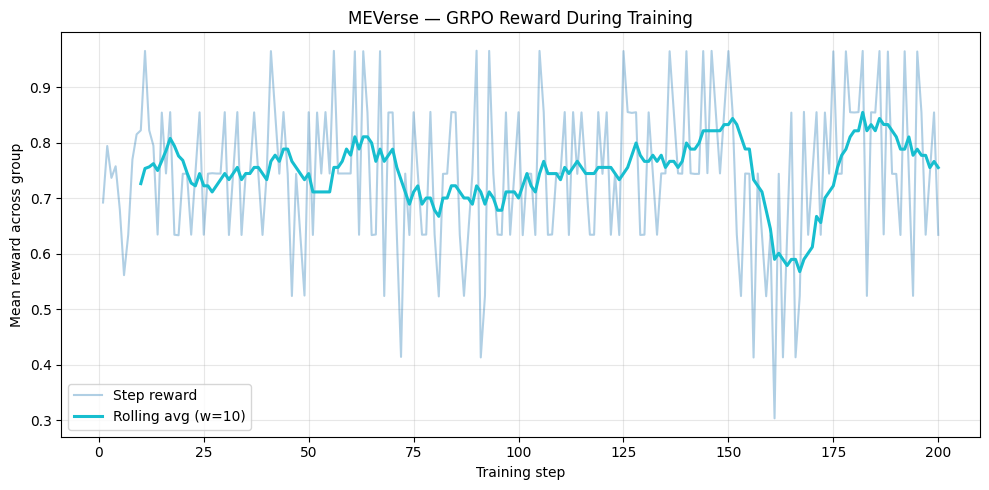

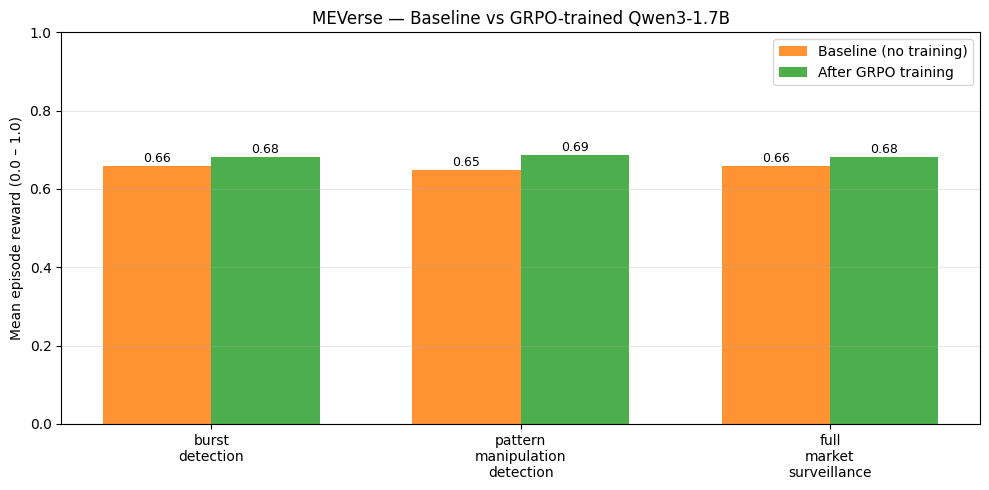

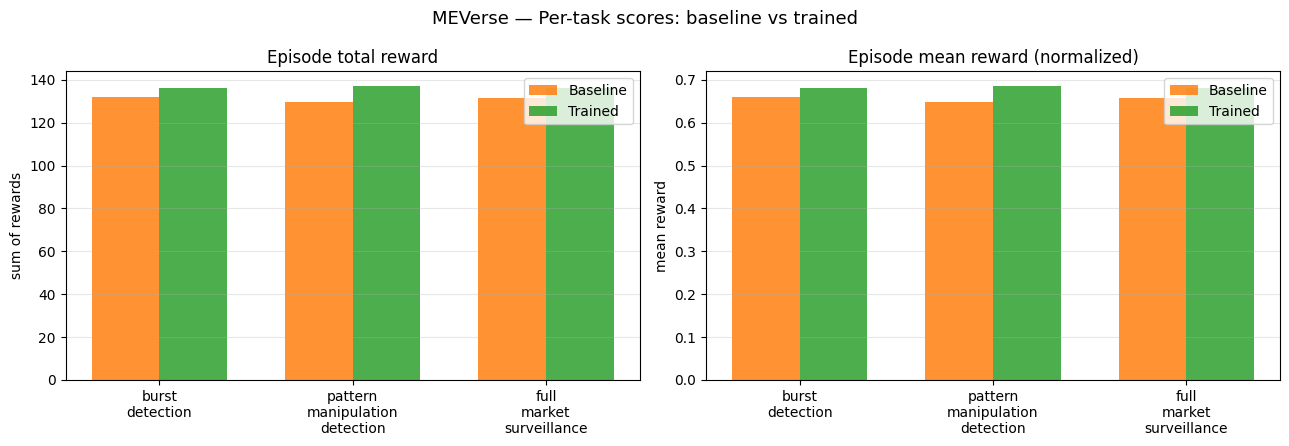


Plots saved to /content/plots/:
total 300
drwxr-xr-x 2 root root   4096 May 26 00:34 .
drwxr-xr-x 1 root root   4096 May 26 00:34 ..
-rw-r--r-- 1 root root  56260 May 26 00:34 baseline_vs_trained.png
-rw-r--r-- 1 root root 174230 May 26 00:34 reward_vs_training_step.png
-rw-r--r-- 1 root root  64743 May 26 00:34 task_scores_comparison.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("/content/plots", exist_ok=True)

# ---------- Plot 1: reward vs training step ----------
log_history = trainer.state.log_history
train_steps = [r["step"] for r in log_history if "reward" in r]
train_rewards = [r["reward"] for r in log_history if "reward" in r]

if train_rewards:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(train_steps, train_rewards, alpha=0.35, color="#1f77b4", label="Step reward")
    if len(train_rewards) >= 10:
        window = max(5, len(train_rewards) // 20)
        rolling = np.convolve(train_rewards, np.ones(window)/window, mode="valid")
        ax.plot(train_steps[window-1:], rolling, color="#17becf", linewidth=2.2,
                label=f"Rolling avg (w={window})")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean reward across group")
    ax.set_title("MEVerse — GRPO Reward During Training")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig("/content/plots/reward_vs_training_step.png", dpi=150)
    plt.show()
else:
    print("No reward column in log_history yet — increase max_steps or check trainer.")

# ---------- Plot 2: baseline vs trained bars ----------
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(TASKS))
width = 0.35
ax.bar(x - width/2, baseline_scores, width, label="Baseline (no training)",
       color="#ff7f0e", alpha=0.85)
ax.bar(x + width/2, trained_scores,  width, label="After GRPO training",
       color="#2ca02c", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([t.replace("_", "\n") for t in TASKS])
ax.set_ylabel("Mean episode reward (0.0 – 1.0)")
ax.set_title("MEVerse — Baseline vs GRPO-trained Qwen3-1.7B")
ax.set_ylim(0, max(1.0, max(trained_scores + baseline_scores) * 1.15))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
for i, (b, t) in enumerate(zip(baseline_scores, trained_scores)):
    ax.text(i - width/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + width/2, t + 0.01, f"{t:.2f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig("/content/plots/baseline_vs_trained.png", dpi=150)
plt.show()

# ---------- Plot 3: per-task total + mean side by side ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# total
b_tot = [r["total_reward"] for r in baseline_results]
t_tot = [r["total_reward"] for r in trained_results]
axes[0].bar(x - width/2, b_tot, width, label="Baseline", color="#ff7f0e", alpha=0.85)
axes[0].bar(x + width/2, t_tot, width, label="Trained",  color="#2ca02c", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([t.replace("_", "\n") for t in TASKS])
axes[0].set_title("Episode total reward"); axes[0].set_ylabel("sum of rewards")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

# mean
axes[1].bar(x - width/2, baseline_scores, width, label="Baseline", color="#ff7f0e", alpha=0.85)
axes[1].bar(x + width/2, trained_scores,  width, label="Trained",  color="#2ca02c", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels([t.replace("_", "\n") for t in TASKS])
axes[1].set_title("Episode mean reward (normalized)"); axes[1].set_ylabel("mean reward")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

fig.suptitle("MEVerse — Per-task scores: baseline vs trained", fontsize=13)
fig.tight_layout()
fig.savefig("/content/plots/task_scores_comparison.png", dpi=150)
plt.show()

print("\nPlots saved to /content/plots/:")
!ls -la /content/plots/

## 10. Save + commit instructions

The Colab runtime is ephemeral — make sure you **download** these before disconnect:

- `/content/plots/*.png` — commit to `plots/` in the GitHub repo so the README can embed them.
- `/content/grpo_outputs/` — LoRA adapters (optional). Push to HF Hub or download zipped.

Below: zip the plots and save the LoRA, then provide a download link.

In [14]:
import shutil

# Save LoRA adapters (PEFT save_pretrained writes adapter_config.json + adapter_model.safetensors)
LORA_DIR = "/content/meverse_qwen_grpo_lora"
trainer.model.save_pretrained(LORA_DIR)
tokenizer.save_pretrained(LORA_DIR)
print(f"LoRA saved to {LORA_DIR}")

# Zip plots
shutil.make_archive("/content/meverse_plots", "zip", "/content/plots")
print("Plots zipped: /content/meverse_plots.zip")

# Zip the LoRA adapter dir
shutil.make_archive("/content/meverse_lora", "zip", LORA_DIR)
print("LoRA zipped:  /content/meverse_lora.zip")

# Suggest download
from google.colab import files  # noqa
print("\nTo download:")
print("  files.download('/content/meverse_plots.zip')")
print("  files.download('/content/meverse_lora.zip')")


LoRA saved to /content/meverse_qwen_grpo_lora
Plots zipped: /content/meverse_plots.zip
LoRA zipped:  /content/meverse_lora.zip

To download:
  files.download('/content/meverse_plots.zip')
  files.download('/content/meverse_lora.zip')


### Push to GitHub (manual step on your local machine after download)

```bash
unzip meverse_plots.zip -d plots/
git add plots/reward_vs_training_step.png \
        plots/baseline_vs_trained.png \
        plots/task_scores_comparison.png
git commit -m "Add GRPO training curves (Qwen3-1.7B + Unsloth GRPO)"
git push
```

### Push LoRA to HF (optional)

```python
model.push_to_hub("your-username/meverse-qwen3-1.7b-grpo", token="hf_...")
tokenizer.push_to_hub("your-username/meverse-qwen3-1.7b-grpo", token="hf_...")
```

---

## Done

You now have:

- ✅ A working GRPO training run using Unsloth + TRL (judge requirement #1)
- ✅ `reward_vs_training_step.png` — proof of training (judge requirement #2)
- ✅ `baseline_vs_trained.png` — proof of *improvement* (Showing Improvement: 20% of grade)
- ✅ A reproducible Colab notebook judges can re-run end-to-end

**Next: link this notebook from the README**, then ping Aarush once the plots are in the repo.